In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv("diabetes_dataset.csv")

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types and non-null counts:")
df.info()

Shape of dataset: (100000, 16)

Column names:
['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']

First 5 rows:


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0



Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 no

In [5]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Target distribution
print("\nDiabetes distribution:")
print(df["diabetes"].value_counts())

print("\nDiabetes proportion:")
print(df["diabetes"].value_counts(normalize=True))

# Summary statistics for numeric variables
df.describe()

Missing values per column:
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

Number of duplicate rows: 14

Diabetes distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Diabetes proportion:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


# EDA

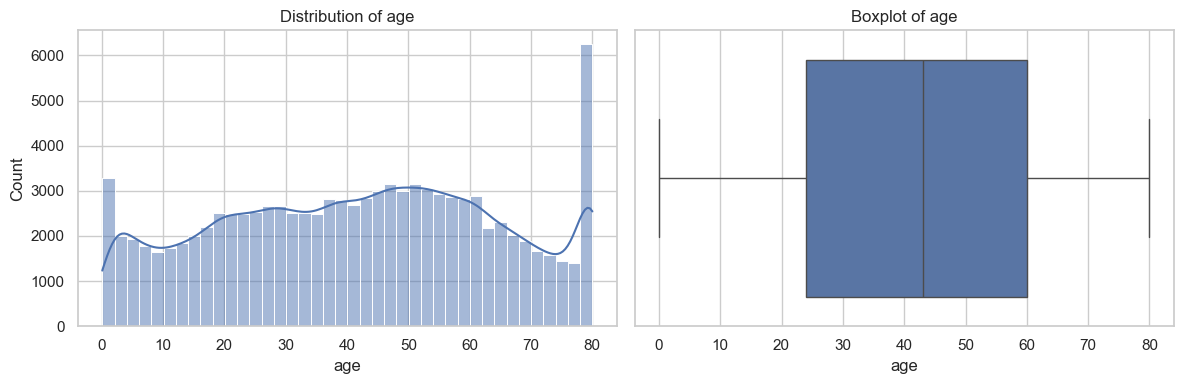

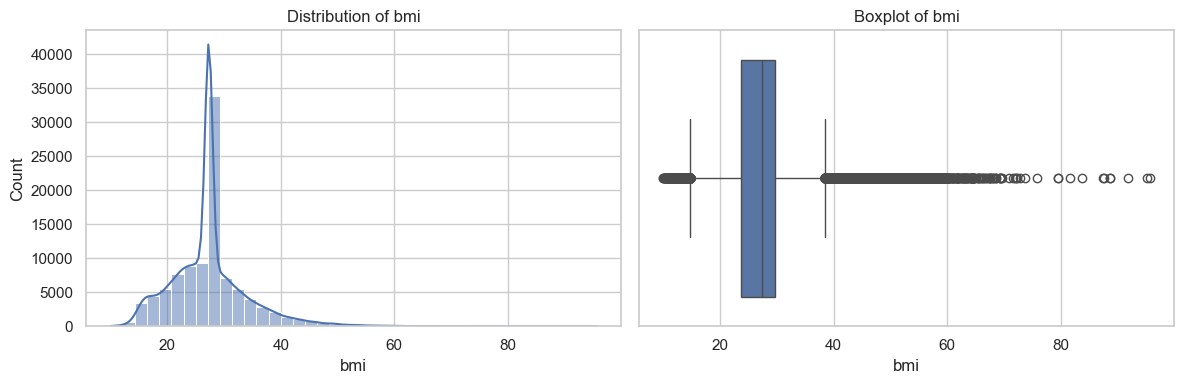

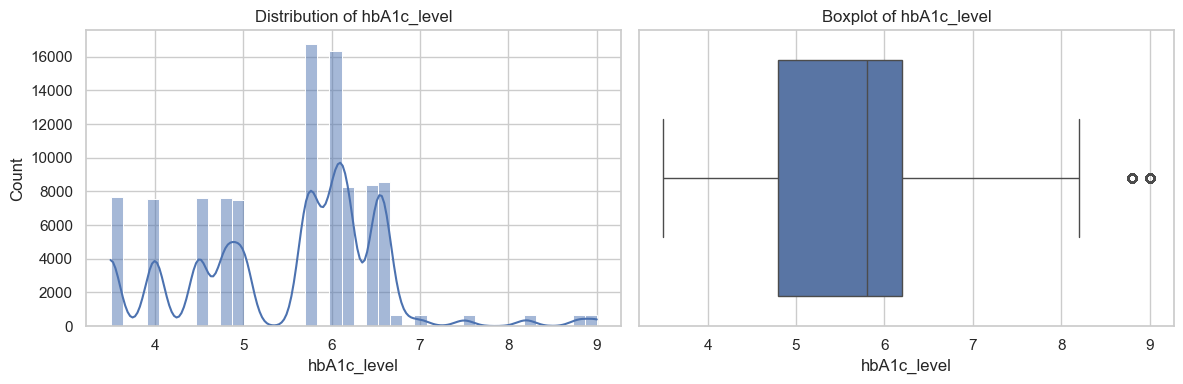

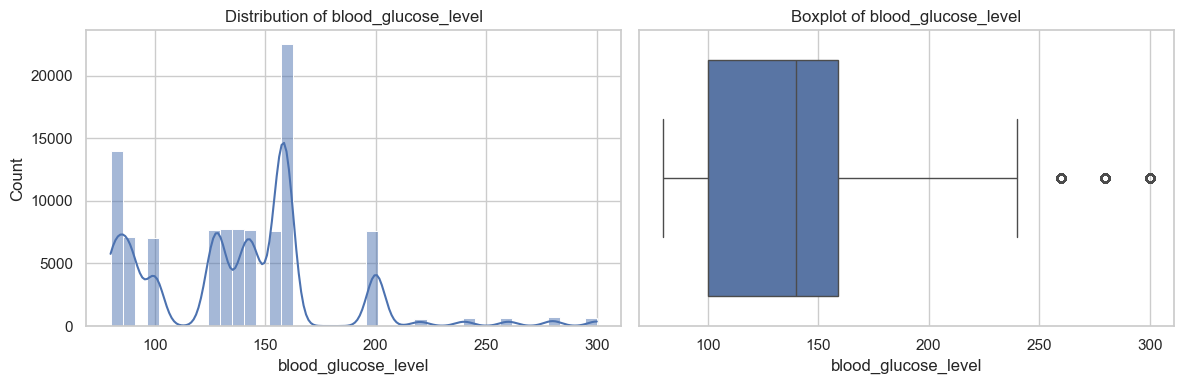

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

numeric_cols = ["age", "bmi", "hbA1c_level", "blood_glucose_level"]

for col in numeric_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram
    sns.histplot(df[col], bins=40, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

## Distribution of Key Numerical Variables

To better understand the characteristics of the dataset, we examined the distributions of four key numerical variables: **age, BMI, HbA1c level, and blood glucose level**. These variables are known to be important clinical indicators associated with diabetes risk.

### Age

The distribution of age spans from infancy to approximately **80 years old**, with a median around the **early 40s**. The histogram shows that the dataset includes a wide range of age groups, suggesting a diverse population. The boxplot indicates no extreme outliers, implying that the age values are generally well distributed and realistic.

### BMI

BMI values are concentrated between **20 and 35**, with a median around **27**, which corresponds to the **overweight category** according to clinical guidelines. The boxplot reveals several high-value outliers above **60**, with a few extreme cases approaching **90**, which may represent rare but possible cases of severe obesity.

### HbA1c Level

HbA1c levels are primarily distributed between **5 and 6.5**, corresponding to the **normal to prediabetic range**. A smaller number of observations exceed **6.5**, which is typically used as a clinical threshold for diagnosing diabetes. The distribution shows several peaks around common clinical measurement values and a slight concentration near the diagnostic threshold.

### Blood Glucose Level

Blood glucose levels are mostly concentrated between **100 and 160**, with several higher values exceeding **200**. These higher observations likely correspond to diabetic individuals. The distribution suggests that blood glucose level contains strong signals for distinguishing diabetic from non-diabetic patients.

### Summary

Overall, the numerical variables show meaningful variation and clinically plausible ranges. In particular, **HbA1c level and blood glucose level appear to be highly informative predictors**, while **BMI and age may also contribute important contextual information for diabetes prediction.

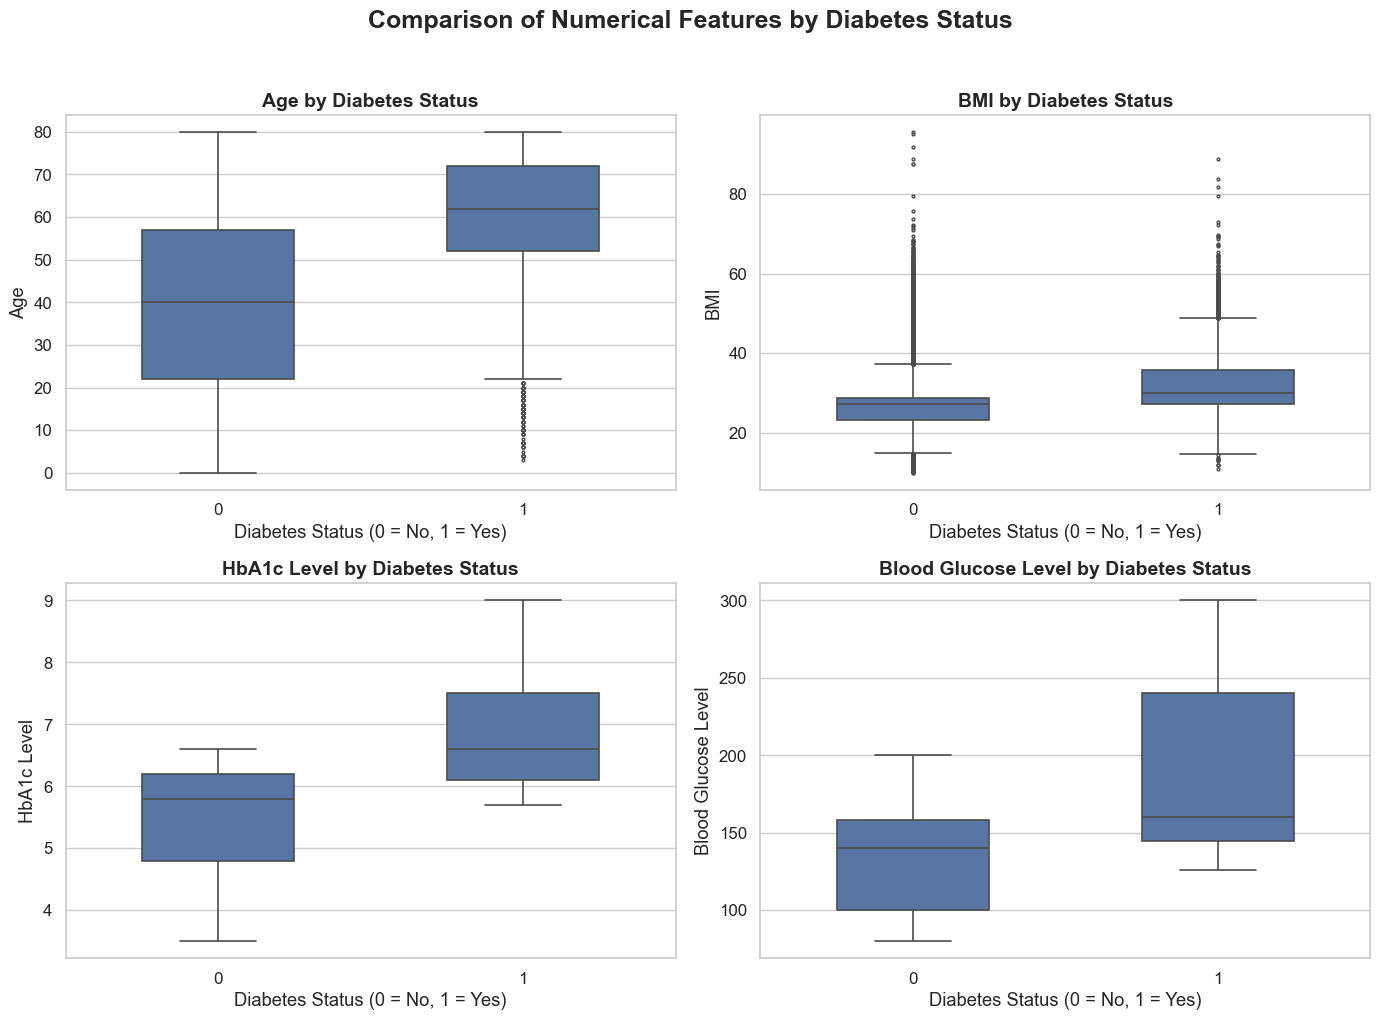

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

numeric_cols = ["age", "bmi", "hbA1c_level", "blood_glucose_level"]
pretty_names = {
    "age": "Age",
    "bmi": "BMI",
    "hbA1c_level": "HbA1c Level",
    "blood_glucose_level": "Blood Glucose Level"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x="diabetes",
        y=col,
        data=df,
        ax=axes[i],
        width=0.5,
        fliersize=2,
        linewidth=1.2
    )
    axes[i].set_title(f"{pretty_names[col]} by Diabetes Status", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Diabetes Status (0 = No, 1 = Yes)")
    axes[i].set_ylabel(pretty_names[col])

plt.suptitle("Comparison of Numerical Features by Diabetes Status", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Relationship Between Numerical Features and Diabetes

To understand how key clinical variables differ between diabetic and non-diabetic patients, we compared the distributions of **age, BMI, HbA1c level, and blood glucose level** across diabetes status using boxplots.

### Age

The boxplot shows that individuals with diabetes tend to be **older on average** than those without diabetes. The median age for diabetic patients is noticeably higher, suggesting that age may be an important risk factor associated with diabetes.

### BMI

BMI values are generally **higher among diabetic patients** compared to non-diabetic individuals. The median BMI of the diabetic group is clearly larger, indicating that higher body mass index may contribute to increased diabetes risk.

### HbA1c Level

A strong separation between the two groups can be observed for **HbA1c levels**. Diabetic individuals have significantly higher HbA1c values, with most observations exceeding the typical clinical threshold of **6.5**. This result aligns with medical knowledge, as HbA1c is commonly used to diagnose diabetes.

### Blood Glucose Level

Blood glucose levels also show a clear difference between the two groups. The diabetic group exhibits substantially higher glucose values, with many observations above **200**, which is consistent with diagnostic criteria for diabetes.

### Summary

Overall, the comparison indicates that **HbA1c level and blood glucose level provide the strongest separation between diabetic and non-diabetic individuals**, while **BMI and age also show noticeable differences**. These variables are therefore expected to be important predictors in the machine learning models used later in the project.

/var/folders/qx/wz3wnl1x3hggb_3d1n2cd_v00000gn/T/ipykernel_2400/2271865056.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels([f"{y*100:.0f}%" for y in axes[i].get_yticks()])
/var/folders/qx/wz3wnl1x3hggb_3d1n2cd_v00000gn/T/ipykernel_2400/2271865056.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels([f"{y*100:.0f}%" for y in axes[i].get_yticks()])
/var/folders/qx/wz3wnl1x3hggb_3d1n2cd_v00000gn/T/ipykernel_2400/2271865056.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels([f"{y*100:.0f}%" for y in axes[i].get_yticks()])
/var/folders/qx/wz3wnl1x3hggb_3d1n2cd_v00000gn/T/ipykernel_2400/2271865056.py:39: UserWarning: set_ticklabels() should only be used with a fixed 

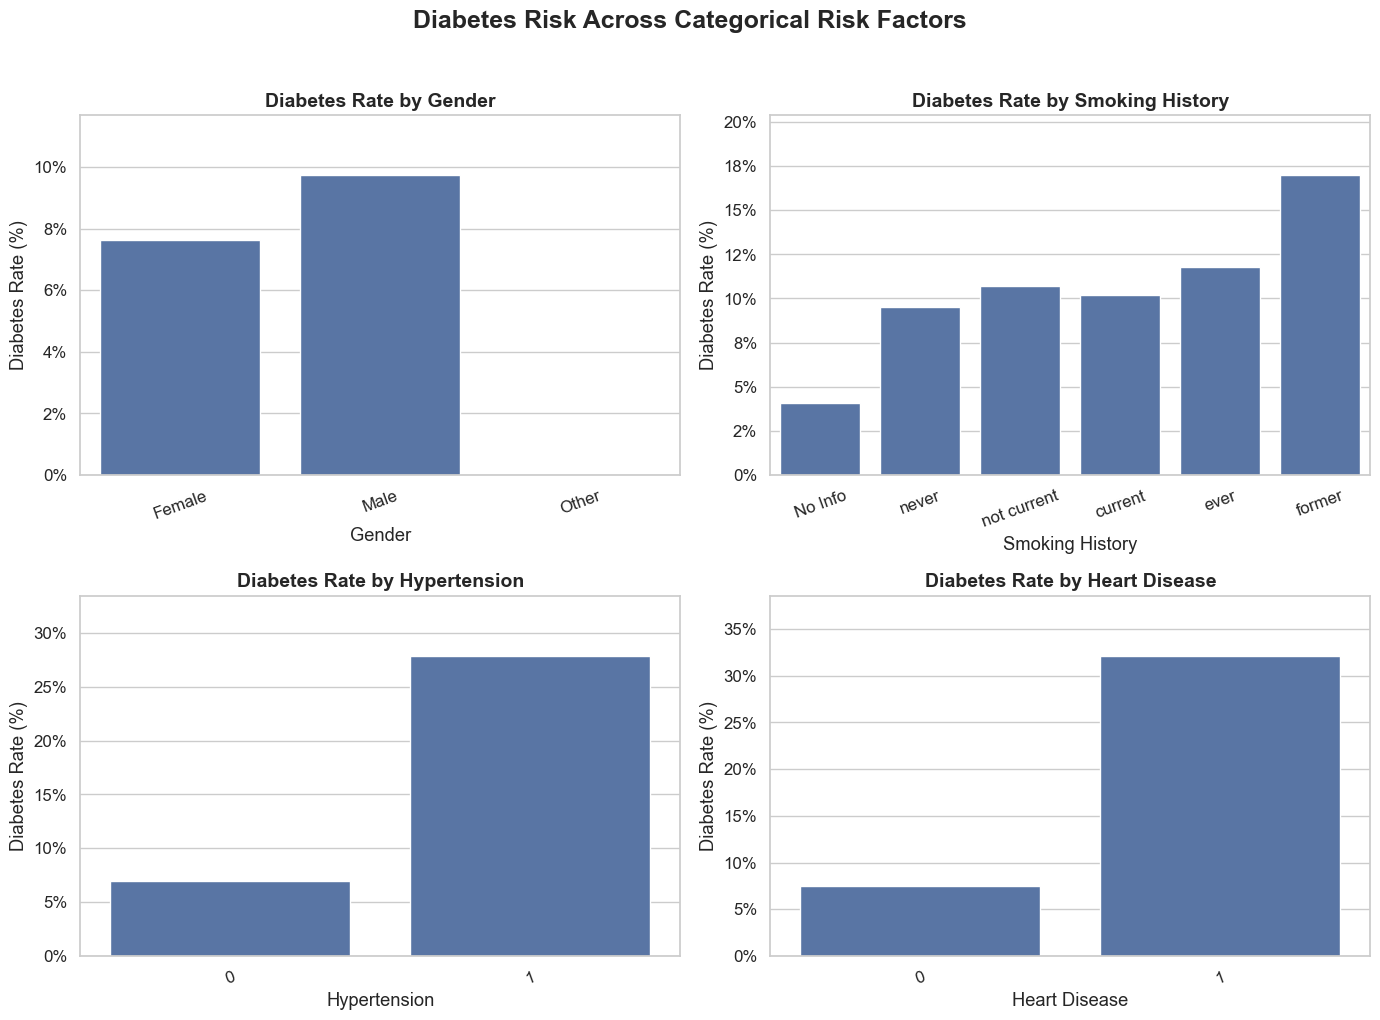

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", font_scale=1.1)

categorical_cols = ["gender", "smoking_history", "hypertension", "heart_disease"]

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.flatten()

# logical order for smoking
smoking_order = ["No Info", "never", "not current", "current", "ever", "former"]

for i, col in enumerate(categorical_cols):

    rate = df.groupby(col)["diabetes"].mean().reset_index()

    if col == "smoking_history":
        rate[col] = pd.Categorical(rate[col], categories=smoking_order, ordered=True)
        rate = rate.sort_values(col)

    sns.barplot(
        data=rate,
        x=col,
        y="diabetes",
        ax=axes[i],
        color="#4C72B0"
    )

    axes[i].set_title(f"Diabetes Rate by {col.replace('_',' ').title()}",
                      fontsize=14, fontweight="bold")

    axes[i].set_xlabel(col.replace("_"," ").title())
    axes[i].set_ylabel("Diabetes Rate (%)")

    axes[i].set_ylim(0, rate["diabetes"].max()*1.2)

    axes[i].set_yticklabels([f"{y*100:.0f}%" for y in axes[i].get_yticks()])

    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Diabetes Risk Across Categorical Risk Factors",
             fontsize=18, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

## Diabetes Risk Across Categorical Risk Factors

To further investigate potential risk factors for diabetes, we examined how the **diabetes prevalence rate varies across several categorical variables**, including gender, smoking history, hypertension, and heart disease.

### Gender

The diabetes rate is slightly higher among **male patients** compared to female patients. This suggests that gender may play a modest role in diabetes prevalence, although the difference is relatively small compared to other risk factors.

### Smoking History

Smoking history shows noticeable differences in diabetes risk. Individuals who **formerly smoked or have ever smoked** exhibit higher diabetes rates compared to those who never smoked. This pattern suggests that long-term lifestyle behaviors such as smoking may contribute to increased diabetes risk.

### Hypertension

A strong difference is observed between individuals **with and without hypertension**. Patients with hypertension have a substantially higher diabetes rate than those without hypertension, indicating that hypertension may be an important comorbidity associated with diabetes.

### Heart Disease

The most pronounced difference appears in heart disease status. Individuals with heart disease show a significantly higher diabetes rate compared to those without heart disease. This finding is consistent with medical literature suggesting strong relationships between cardiovascular conditions and metabolic disorders.

### Summary

Overall, the analysis indicates that **hypertension and heart disease are strongly associated with higher diabetes prevalence**, while **smoking history and gender also show meaningful differences**. These categorical features are therefore likely to provide useful information for predicting diabetes in the subsequent machine learning models.

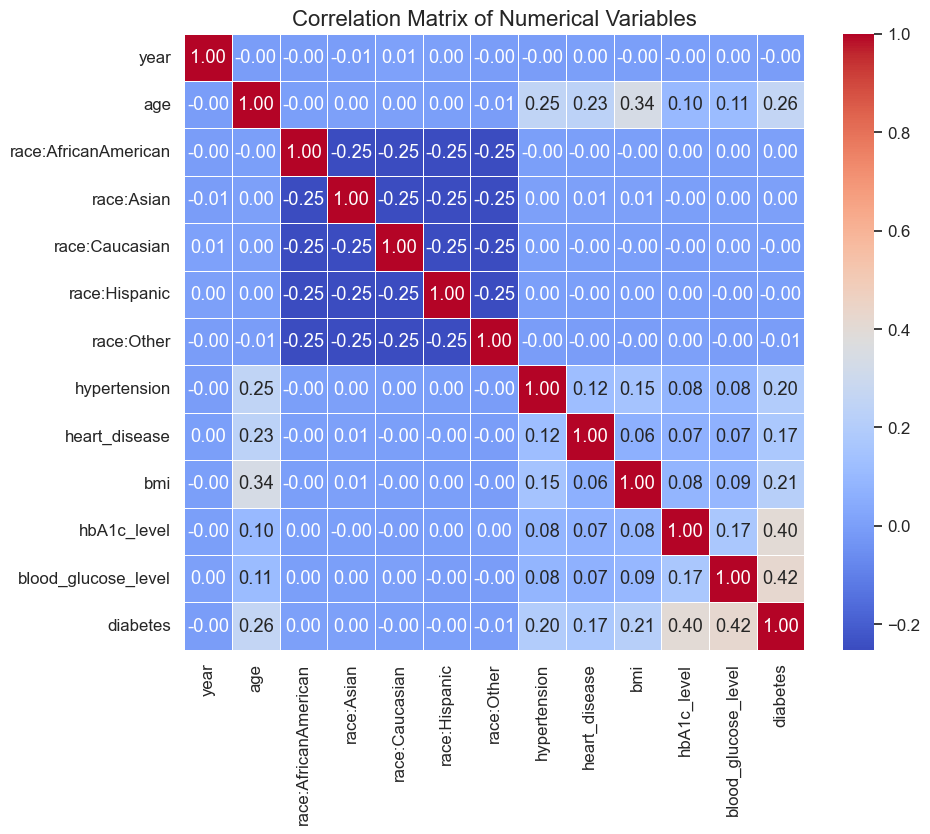

In [9]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16)
plt.show()

## Correlation Analysis of Numerical Variables

To further understand relationships among the numerical variables, we computed the **Pearson correlation matrix** and visualized it using a heatmap. This analysis helps identify potential relationships between predictors and the target variable, as well as possible redundancy among features.

### Correlation with Diabetes

Among all variables, **blood glucose level** and **HbA1c level** show the strongest positive correlations with diabetes.

- **Blood glucose level (0.42)** shows the highest correlation with diabetes, which is expected since elevated blood glucose is a key diagnostic indicator of diabetes.
- **HbA1c level (0.40)** also demonstrates a strong positive relationship with diabetes, reflecting its clinical role as a long-term blood sugar indicator.

Other variables show moderate associations:

- **Age (0.26)** indicates that older individuals tend to have a higher probability of diabetes.
- **BMI (0.21)** suggests that higher body mass index is associated with increased diabetes risk.
- **Hypertension (0.20)** and **heart disease (0.17)** also show positive correlations with diabetes, consistent with known comorbidities.

### Relationships Among Predictors

Some moderate relationships are also observed among predictor variables:

- **Age and BMI (0.34)** show a moderate positive relationship.
- **Age and hypertension (0.25)** suggest that hypertension becomes more common with increasing age.

Race indicator variables show negative correlations with each other because they represent **mutually exclusive categories** (one-hot encoded race groups).

### Summary

Overall, the correlation analysis confirms that **HbA1c level and blood glucose level are the most informative predictors for diabetes**, while **age, BMI, hypertension, and heart disease provide additional predictive signals**. These findings align with both medical knowledge and the earlier exploratory data analysis.

# Feature Engineering

In [10]:
drop_cols = ['year', 'location', 
             'race:AfricanAmerican', 'race:Asian', 
             'race:Caucasian', 'race:Hispanic', 'race:Other']

df = df.drop(columns=drop_cols)

print(f"Dropped {len(drop_cols)} columns")
print(f"Remaining columns: {list(df.columns)}")
print(f"New shape: {df.shape}")

Dropped 7 columns
Remaining columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']
New shape: (100000, 9)


In [11]:
# Drop the 18 "Other" rows (0.018% of data - negligible loss)
df = df[df['gender'] != 'Other']

# Binary encode: Female = 0, Male = 1
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

print("=== Gender After Encoding ===")
print(df['gender'].value_counts())
print(f"\nRows remaining: {len(df)}")

=== Gender After Encoding ===
gender
0    58552
1    41430
Name: count, dtype: int64

Rows remaining: 99982


In [12]:
smoking_order = {
    'No Info': 0,
    'never': 1,
    'current': 2,
    'not current': 3,
    'ever': 4,
    'former': 5
}

df['smoking_history'] = df['smoking_history'].map(smoking_order)

print("=== Smoking History After Encoding ===")
print(df['smoking_history'].value_counts().sort_index())

=== Smoking History After Encoding ===
smoking_history
0    35810
1    35092
2     9286
3     6439
4     4003
5     9352
Name: count, dtype: int64


In [13]:
bmi_cap = df['bmi'].quantile(0.99)
print(f"BMI 99th percentile: {bmi_cap}")
print(f"BMI values above cap before: {(df['bmi'] > bmi_cap).sum()}")

df['bmi'] = df['bmi'].clip(upper=bmi_cap)

print(f"BMI max after capping: {df['bmi'].max()}")

BMI 99th percentile: 48.79190000000002
BMI values above cap before: 1000
BMI max after capping: 48.79190000000002


In [14]:
bins = [0, 18, 35, 50, 65, 80]
labels = ['0-18', '19-35', '36-50', '51-65', '66-80']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Check diabetes rate per age group
print("=== Diabetes Rate by Age Group ===")
print(df.groupby('age_group')['diabetes'].mean().round(3))
print("\n=== Count by Age Group ===")
print(df['age_group'].value_counts().sort_index())

# One-hot encode the age groups
age_dummies = pd.get_dummies(df['age_group'], prefix='age', dtype=int)
df = pd.concat([df, age_dummies], axis=1)
df = df.drop(columns=['age_group'])

print(f"\nNew columns added: {list(age_dummies.columns)}")

=== Diabetes Rate by Age Group ===
age_group
0-18     0.005
19-35    0.018
36-50    0.064
51-65    0.147
66-80    0.204
Name: diabetes, dtype: float64

=== Count by Age Group ===
age_group
0-18     18395
19-35    21582
36-50    21545
51-65    21026
66-80    17434
Name: count, dtype: int64

New columns added: ['age_0-18', 'age_19-35', 'age_36-50', 'age_51-65', 'age_66-80']


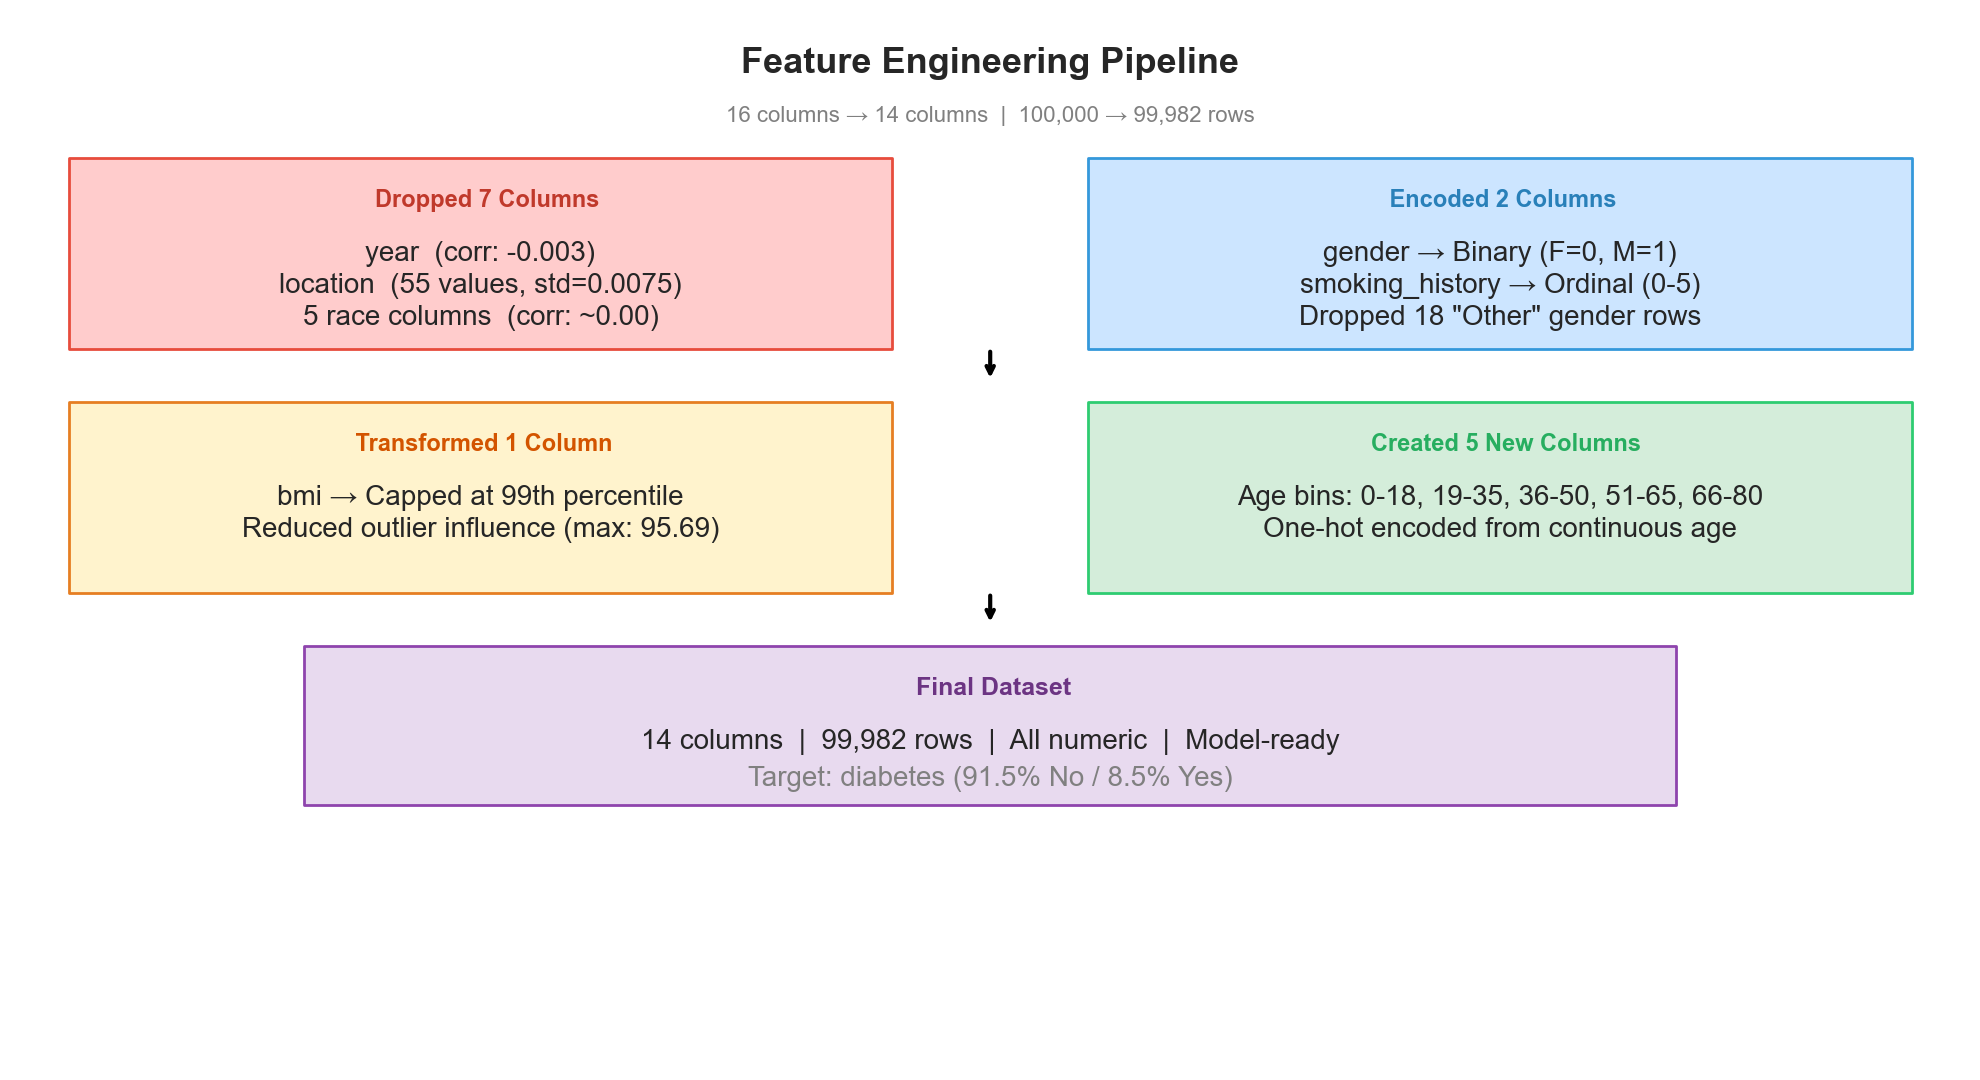

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(20, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Feature Engineering Pipeline', fontsize=26, fontweight='bold',
        ha='center', va='center')
ax.text(5, 9.0, '16 columns → 14 columns  |  100,000 → 99,982 rows',
        fontsize=16, ha='center', va='center', color='gray')

# --- STEP 1: Dropped Features ---
ax.add_patch(plt.Rectangle((0.3, 6.8), 4.2, 1.8, facecolor='#ffcccc', edgecolor='#e74c3c',
                            linewidth=2, zorder=1, joinstyle='round'))
ax.text(2.4, 8.2, '  Dropped 7 Columns', fontsize=17, fontweight='bold',
        ha='center', va='center', color='#c0392b')
ax.text(2.4, 7.7, 'year  (corr: -0.003)', fontsize=20, ha='center', va='center')
ax.text(2.4, 7.4, 'location  (55 values, std=0.0075)', fontsize=20, ha='center', va='center')
ax.text(2.4, 7.1, '5 race columns  (corr: ~0.00)', fontsize=20, ha='center', va='center')

# --- STEP 2: Encoded Features ---
ax.add_patch(plt.Rectangle((5.5, 6.8), 4.2, 1.8, facecolor='#cce5ff', edgecolor='#3498db',
                            linewidth=2, zorder=1, joinstyle='round'))
ax.text(7.6, 8.2, ' Encoded 2 Columns', fontsize=17, fontweight='bold',
        ha='center', va='center', color='#2980b9')
ax.text(7.6, 7.7, 'gender → Binary (F=0, M=1)', fontsize=20, ha='center', va='center')
ax.text(7.6, 7.4, 'smoking_history → Ordinal (0-5)', fontsize=20, ha='center', va='center')
ax.text(7.6, 7.1, 'Dropped 18 "Other" gender rows', fontsize=20, ha='center', va='center')

# Arrow down
ax.annotate('', xy=(5, 6.5), xytext=(5, 6.8),
            arrowprops=dict(arrowstyle='->', color='black', lw=3))

# --- STEP 3: Transformed ---
ax.add_patch(plt.Rectangle((0.3, 4.5), 4.2, 1.8, facecolor='#fff3cd', edgecolor='#e67e22',
                            linewidth=2, zorder=1, joinstyle='round'))
ax.text(2.4, 5.9, ' Transformed 1 Column', fontsize=17, fontweight='bold',
        ha='center', va='center', color='#d35400')
ax.text(2.4, 5.4, 'bmi → Capped at 99th percentile', fontsize=20, ha='center', va='center')
ax.text(2.4, 5.1, 'Reduced outlier influence (max: 95.69)', fontsize=20, ha='center', va='center')

# --- STEP 4: Created Features ---
ax.add_patch(plt.Rectangle((5.5, 4.5), 4.2, 1.8, facecolor='#d4edda', edgecolor='#2ecc71',
                            linewidth=2, zorder=1, joinstyle='round'))
ax.text(7.6, 5.9, '  Created 5 New Columns', fontsize=17, fontweight='bold',
        ha='center', va='center', color='#27ae60')
ax.text(7.6, 5.4, 'Age bins: 0-18, 19-35, 36-50, 51-65, 66-80', fontsize=20,
        ha='center', va='center')
ax.text(7.6, 5.1, 'One-hot encoded from continuous age', fontsize=20, ha='center', va='center')

# Arrow down
ax.annotate('', xy=(5, 4.2), xytext=(5, 4.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=3))

# --- FINAL RESULT ---
ax.add_patch(plt.Rectangle((1.5, 2.5), 7, 1.5, facecolor='#e8daef', edgecolor='#8e44ad',
                            linewidth=2, zorder=1, joinstyle='round'))
ax.text(5, 3.6, ' Final Dataset', fontsize=18, fontweight='bold',
        ha='center', va='center', color='#6c3483')
ax.text(5, 3.1, '14 columns  |  99,982 rows  |  All numeric  |  Model-ready',
        fontsize=20, ha='center', va='center')
ax.text(5, 2.75, 'Target: diabetes (91.5% No / 8.5% Yes)',
        fontsize=20, ha='center', va='center', color='gray')

plt.tight_layout()
plt.savefig('feature_engineering_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# Train - Test Split

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# 80/20 split with stratify to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 79985 rows
Test set: 19997 rows

Training set class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Test set class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


# Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

# Scale features - important for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaling complete")
print(f"\nBefore scaling - BMI mean: {X_train['bmi'].mean():.2f}, std: {X_train['bmi'].std():.2f}")
print(f"After scaling - BMI mean: {X_train_scaled['bmi'].mean():.2f}, std: {X_train_scaled['bmi'].std():.2f}")

Scaling complete

Before scaling - BMI mean: 27.26, std: 6.41
After scaling - BMI mean: 0.00, std: 1.00


# Model Building
## Deal with Class Imbalance
### Baseline — No Imbalance Handling

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Baseline: plain Logistic Regression with no imbalance handling
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_baseline = baseline_model.predict(X_test_scaled)

print("=== BASELINE: No Imbalance Handling ===")
print(classification_report(y_test, y_pred_baseline, target_names=['No Diabetes', 'Diabetes']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

=== BASELINE: No Imbalance Handling ===
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     18297
    Diabetes       0.88      0.64      0.74      1700

    accuracy                           0.96     19997
   macro avg       0.92      0.81      0.86     19997
weighted avg       0.96      0.96      0.96     19997

Confusion Matrix:
[[18145   152]
 [  619  1081]]


### Class Weighting

In [20]:
# From the Modeling section of the HTML
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_weighted = lr_model.predict(X_test_scaled) # This is where the predictions were stored

=== Logistic Regression: Test Set Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.93     18297
    Diabetes       0.42      0.87      0.57      1700

    accuracy                           0.89     19997
   macro avg       0.70      0.88      0.75     19997
weighted avg       0.94      0.89      0.90     19997



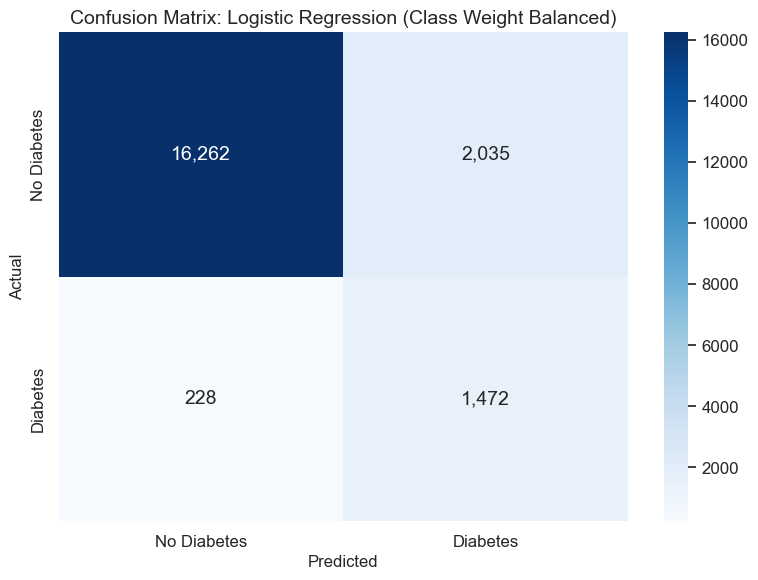

True Negatives (TN):  16,262 — Healthy patients correctly identified
False Positives (FP): 2,035 — Healthy patients wrongly flagged as diabetic
False Negatives (FN): 228 — Diabetic patients missed
True Positives (TP):  1,472 — Diabetic patients correctly caught

False Positive Rate (FPR): 0.111 — 11.1% of healthy patients were wrongly flagged
False Negative Rate (FNR): 0.134 — 13.4% of diabetic patients were missed


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Print classification report
print("=== Logistic Regression: Test Set Classification Report ===")
print(classification_report(y_test, y_pred_weighted, target_names=['No Diabetes', 'Diabetes']))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_weighted)

# Extract values
TN, FP, FN, TP = cm.ravel()

# Calculate FPR and FNR
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix: Logistic Regression (Class Weight Balanced)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('cm_lr_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives (TN):  {TN:,} — Healthy patients correctly identified")
print(f"False Positives (FP): {FP:,} — Healthy patients wrongly flagged as diabetic")
print(f"False Negatives (FN): {FN:,} — Diabetic patients missed")
print(f"True Positives (TP):  {TP:,} — Diabetic patients correctly caught")

print(f"\nFalse Positive Rate (FPR): {FPR:.3f} — {FPR*100:.1f}% of healthy patients were wrongly flagged")
print(f"False Negative Rate (FNR): {FNR:.3f} — {FNR*100:.1f}% of diabetic patients were missed")

### Undersampling

In [22]:
from imblearn.under_sampling import RandomUnderSampler

# Technique 2: Random Undersampling
# Reduce majority class to match minority class size
# ONLY applied to training data

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print(f"Before undersampling: {y_train.value_counts().to_dict()}")
print(f"After undersampling: {pd.Series(y_train_under).value_counts().to_dict()}")

# Train on undersampled data
under_model = LogisticRegression(random_state=42, max_iter=1000)
under_model.fit(X_train_under, y_train_under)

# Predict on ORIGINAL test set (not undersampled)
y_pred_under = under_model.predict(X_test_scaled)

print("\n=== TECHNIQUE 2: Random Undersampling ===")
print(classification_report(y_test, y_pred_under, target_names=['No Diabetes', 'Diabetes']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_under))

Before undersampling: {0: 73185, 1: 6800}
After undersampling: {0: 6800, 1: 6800}

=== TECHNIQUE 2: Random Undersampling ===
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.93     18297
    Diabetes       0.42      0.86      0.56      1700

    accuracy                           0.89     19997
   macro avg       0.70      0.88      0.75     19997
weighted avg       0.94      0.89      0.90     19997

Confusion Matrix:
[[16260  2037]
 [  230  1470]]


### SMOTE

In [23]:
from imblearn.over_sampling import SMOTE

# Technique 3: SMOTE
# Generate synthetic minority samples to match majority class size
# ONLY applied to training data

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

# Train on SMOTE data
smote_model = LogisticRegression(random_state=42, max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)

# Predict on ORIGINAL test set
y_pred_smote = smote_model.predict(X_test_scaled)

print("\n=== TECHNIQUE 3: SMOTE (Oversampling) ===")
print(classification_report(y_test, y_pred_smote, target_names=['No Diabetes', 'Diabetes']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Before SMOTE: {0: 73185, 1: 6800}
After SMOTE: {0: 73185, 1: 73185}

=== TECHNIQUE 3: SMOTE (Oversampling) ===
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     18297
    Diabetes       0.42      0.86      0.57      1700

    accuracy                           0.89     19997
   macro avg       0.70      0.88      0.75     19997
weighted avg       0.94      0.89      0.90     19997

Confusion Matrix:
[[16277  2020]
 [  231  1469]]


In [24]:
from sklearn.metrics import f1_score, recall_score, precision_score

# Collect results
results = {
    'Technique': ['Baseline (No Handling)', 'Class Weight Balanced', 
                  'Random Undersampling', 'SMOTE'],
    'Precision (Diabetes)': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_under),
        precision_score(y_test, y_pred_smote)
    ],
    'Recall (Diabetes)': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_smote)
    ],
    'F1-Score (Diabetes)': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_smote)
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(3)
print("=== Imbalance Technique Comparison ===")
print(comparison_df.to_string(index=False))

=== Imbalance Technique Comparison ===
             Technique  Precision (Diabetes)  Recall (Diabetes)  F1-Score (Diabetes)
Baseline (No Handling)                 0.877              0.636                0.737
 Class Weight Balanced                 0.420              0.866                0.565
  Random Undersampling                 0.419              0.865                0.565
                 SMOTE                 0.421              0.864                0.566


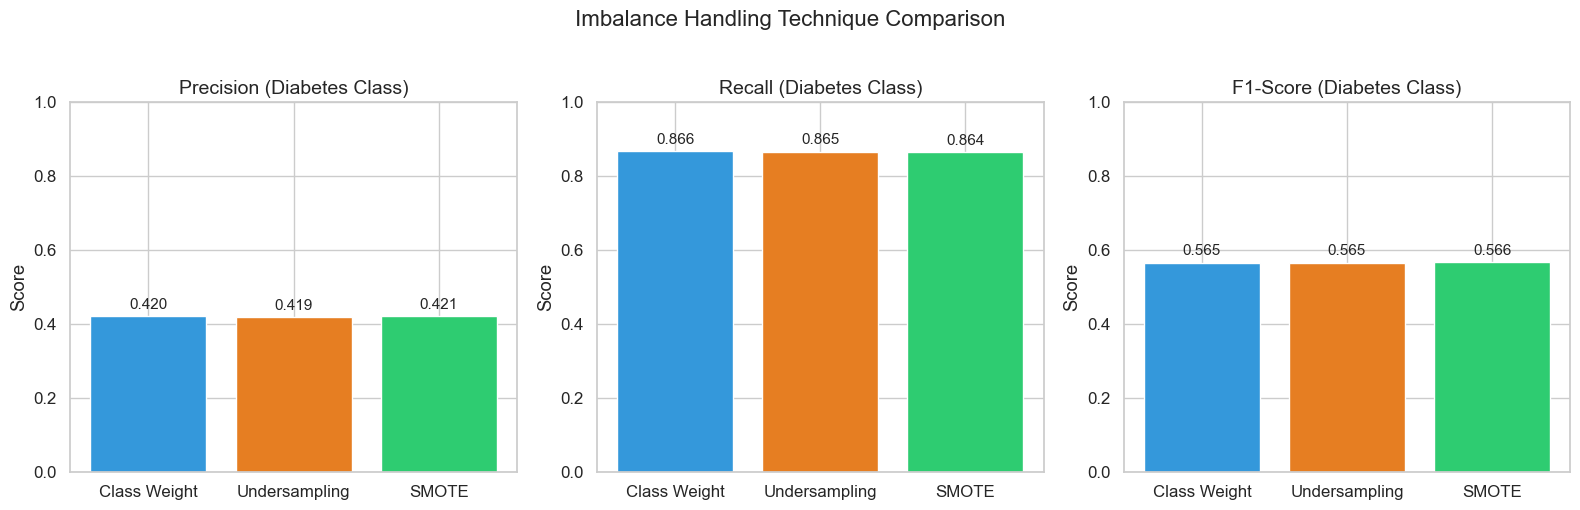

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

techniques = ['Class Weight', 'Undersampling', 'SMOTE']
colors = ['#3498db', '#e67e22', '#2ecc71']

# Filter out baseline row
filtered_df = comparison_df[comparison_df['Technique'] != 'Baseline (No Handling)'].reset_index(drop=True)

# Precision
axes[0].bar(techniques, filtered_df['Precision (Diabetes)'], color=colors)
axes[0].set_title('Precision (Diabetes Class)', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(filtered_df['Precision (Diabetes)']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

# Recall
axes[1].bar(techniques, filtered_df['Recall (Diabetes)'], color=colors)
axes[1].set_title('Recall (Diabetes Class)', fontsize=14)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
for i, v in enumerate(filtered_df['Recall (Diabetes)']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

# F1-Score
axes[2].bar(techniques, filtered_df['F1-Score (Diabetes)'], color=colors)
axes[2].set_title('F1-Score (Diabetes Class)', fontsize=14)
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1)
for i, v in enumerate(filtered_df['F1-Score (Diabetes)']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.suptitle('Imbalance Handling Technique Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Logistic Regression

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [28]:
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

cv_results_lr = cross_validate(
    lr_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== Logistic Regression: 5-Fold CV Results ===")
print(f"Precision: {cv_results_lr['test_precision'].mean():.3f} (+/- {cv_results_lr['test_precision'].std():.3f})")
print(f"Recall:    {cv_results_lr['test_recall'].mean():.3f} (+/- {cv_results_lr['test_recall'].std():.3f})")
print(f"F1-Score:  {cv_results_lr['test_f1'].mean():.3f} (+/- {cv_results_lr['test_f1'].std():.3f})")

=== Logistic Regression: 5-Fold CV Results ===
Precision: 0.422 (+/- 0.007)
Recall:    0.884 (+/- 0.004)
F1-Score:  0.571 (+/- 0.006)


In [48]:
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

## Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=6,
    min_samples_split=30,
    min_samples_leaf=15
)

# Run CV on training data only
cv_results_dt = cross_validate(
    dt_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== Decision Tree: 5-Fold CV Results ===")
print(f"Precision: {cv_results_dt['test_precision'].mean():.3f} ")
print(f"Recall:    {cv_results_dt['test_recall'].mean():.3f} ")
print(f"F1-Score:  {cv_results_dt['test_f1'].mean():.3f} ")

=== Decision Tree: 5-Fold CV Results ===
Precision: 0.398 
Recall:    0.914 
F1-Score:  0.547 


In [33]:
dt_model.fit(X_train_scaled, y_train)
y_train_pred_dt = dt_model.predict(X_train_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)
# Calculate gaps
train_precision_dt = precision_score(y_train, y_train_pred_dt)
train_recall_dt = recall_score(y_train, y_train_pred_dt)
train_f1_dt = f1_score(y_train, y_train_pred_dt)

test_precision_dt = precision_score(y_test, y_pred_dt)
test_recall_dt = recall_score(y_test, y_pred_dt)
test_f1_dt = f1_score(y_test, y_pred_dt)

fit_check_dt = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Training': [train_precision_dt, train_recall_dt, train_f1_dt],
    'Test': [test_precision_dt, test_recall_dt, test_f1_dt],
    'Gap': [train_precision_dt - test_precision_dt, 
            train_recall_dt - test_recall_dt, 
            train_f1_dt - test_f1_dt]
})
fit_check_dt = fit_check_dt.round(3)

print("=== Decision Tree: Overfitting Check ===")
print(fit_check_dt.to_string(index=False))

f1_gap_dt = train_f1_dt - test_f1_dt
if f1_gap_dt > 0.10:
    print(f"\nF1 gap = {f1_gap_dt:.3f} → OVERFITTING")
elif f1_gap_dt < 0.02:
    print(f"\nF1 gap = {f1_gap_dt:.3f} → WELL-FITTED")
else:
    print(f"\nF1 gap = {f1_gap_dt:.3f} → SLIGHT OVERFITTING")

=== Decision Tree: Overfitting Check ===
   Metric  Training  Test   Gap
Precision     0.353 0.350 0.003
   Recall     0.944 0.928 0.015
 F1-Score     0.513 0.508 0.005

F1 gap = 0.005 → WELL-FITTED


## Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,            # Limit how deep each tree can grow
    min_samples_split=20,    # Require at least 20 samples to split a node
    min_samples_leaf=10      # Each leaf must have at least 10 samples
)

In [35]:
# 5-Fold Stratified Cross-Validation
cv_results_rf = cross_validate(
    rf_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== Random Forest: 5-Fold CV Results ===")
print(f"Precision: {cv_results_rf['test_precision'].mean():.3f}")
print(f"Recall:    {cv_results_rf['test_recall'].mean():.3f}")
print(f"F1-Score:  {cv_results_rf['test_f1'].mean():.3f}")

=== Random Forest: 5-Fold CV Results ===
Precision: 0.467
Recall:    0.913
F1-Score:  0.618


In [38]:
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

=== Random Forest: Test Set Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.99      0.90      0.95     18297
    Diabetes       0.47      0.91      0.62      1700

    accuracy                           0.90     19997
   macro avg       0.73      0.91      0.78     19997
weighted avg       0.95      0.90      0.92     19997



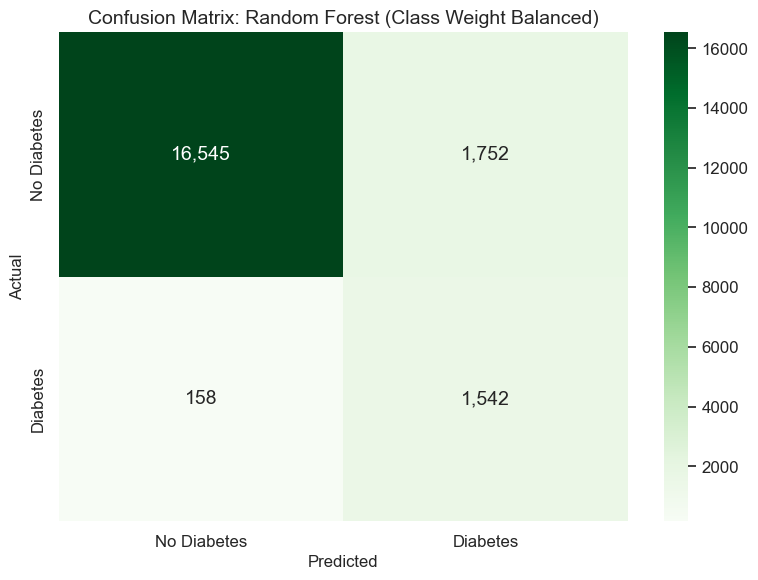

True Negatives (TN):  16,545 — Healthy patients correctly identified
False Positives (FP): 1,752 — Healthy patients wrongly flagged as diabetic
False Negatives (FN): 158 — Diabetic patients missed
True Positives (TP):  1,542 — Diabetic patients correctly caught

False Positive Rate (FPR): 0.096 — 9.6% of healthy patients were wrongly flagged
False Negative Rate (FNR): 0.093 — 9.3% of diabetic patients were missed


In [39]:
# Print classification report
print("=== Random Forest: Test Set Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Diabetes', 'Diabetes']))

# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Extract values
TN, FP, FN, TP = cm_rf.ravel()

# Calculate FPR and FNR
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt=',', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix: Random Forest (Class Weight Balanced)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('cm_rf_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives (TN):  {TN:,} — Healthy patients correctly identified")
print(f"False Positives (FP): {FP:,} — Healthy patients wrongly flagged as diabetic")
print(f"False Negatives (FN): {FN:,} — Diabetic patients missed")
print(f"True Positives (TP):  {TP:,} — Diabetic patients correctly caught")

print(f"\nFalse Positive Rate (FPR): {FPR:.3f} — {FPR*100:.1f}% of healthy patients were wrongly flagged")
print(f"False Negative Rate (FNR): {FNR:.3f} — {FNR*100:.1f}% of diabetic patients were missed")

## XGBoost

In [40]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight (equivalent of class_weight='balanced' for XGBoost)
# It's the ratio of negative to positive samples
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_ratio:.2f}")

# Initialize XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=scale_ratio,
    random_state=42,
    eval_metric='logloss',
    n_estimators=100
)

scale_pos_weight = 10.76


In [41]:
cv_results_xgb = cross_validate(
    xgb_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== XGBoost: 5-Fold CV Results ===")
print(f"Precision: {cv_results_xgb['test_precision'].mean():.3f} ")
print(f"Recall:    {cv_results_xgb['test_recall'].mean():.3f} ")
print(f"F1-Score:  {cv_results_xgb['test_f1'].mean():.3f} ")

=== XGBoost: 5-Fold CV Results ===
Precision: 0.528 
Recall:    0.873 
F1-Score:  0.658 


In [42]:
cv_results_xgb = cross_validate(
    xgb_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

print("=== XGBoost: 5-Fold CV Results ===")
print(f"Precision: {cv_results_xgb['test_precision'].mean():.3f} ")
print(f"Recall:    {cv_results_xgb['test_recall'].mean():.3f} ")
print(f"F1-Score:  {cv_results_xgb['test_f1'].mean():.3f} ")

=== XGBoost: 5-Fold CV Results ===
Precision: 0.528 
Recall:    0.873 
F1-Score:  0.658 


=== XGBoost: Test Set Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.99      0.92      0.95     18297
    Diabetes       0.52      0.88      0.65      1700

    accuracy                           0.92     19997
   macro avg       0.75      0.90      0.80     19997
weighted avg       0.95      0.92      0.93     19997



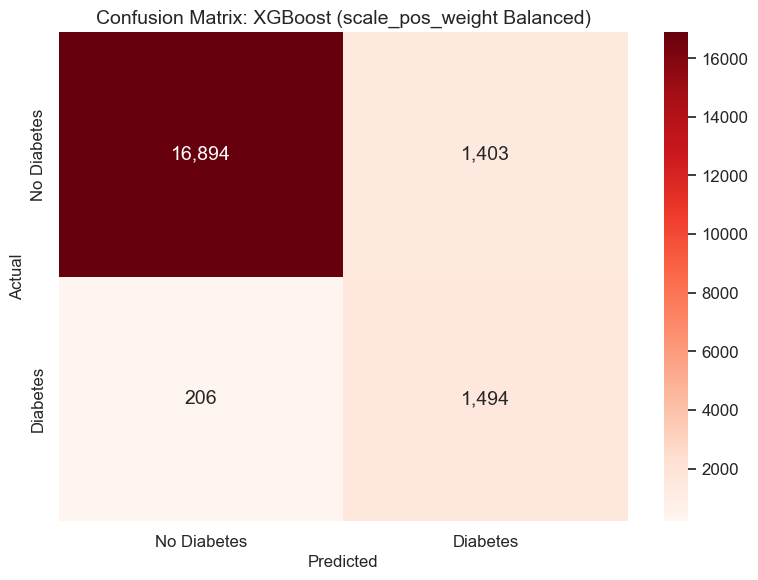

True Negatives (TN):  16,894 — Healthy patients correctly identified
False Positives (FP): 1,403 — Healthy patients wrongly flagged as diabetic
False Negatives (FN): 206 — Diabetic patients missed
True Positives (TP):  1,494 — Diabetic patients correctly caught

False Positive Rate (FPR): 0.077 — 7.7% of healthy patients were wrongly flagged
False Negative Rate (FNR): 0.121 — 12.1% of diabetic patients were missed


In [44]:
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
# Print classification report
print("=== XGBoost: Test Set Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Diabetes', 'Diabetes']))

# Generate confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Extract values
TN, FP, FN, TP = cm_xgb.ravel()

# Calculate FPR and FNR
FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Reds',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix: XGBoost (scale_pos_weight Balanced)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('cm_xgb_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives (TN):  {TN:,} — Healthy patients correctly identified")
print(f"False Positives (FP): {FP:,} — Healthy patients wrongly flagged as diabetic")
print(f"False Negatives (FN): {FN:,} — Diabetic patients missed")
print(f"True Positives (TP):  {TP:,} — Diabetic patients correctly caught")

print(f"\nFalse Positive Rate (FPR): {FPR:.3f} — {FPR*100:.1f}% of healthy patients were wrongly flagged")
print(f"False Negative Rate (FNR): {FNR:.3f} — {FNR*100:.1f}% of diabetic patients were missed")

In [45]:
comparison = pd.DataFrame({
    'Metric': ['Precision (CV)', 'Recall (CV)', 'F1-Score (CV)',
               'Precision (Test)', 'Recall (Test)', 'F1-Score (Test)'],
    'LR': [
        f"{cv_results_lr['test_precision'].mean():.3f} ",
        f"{cv_results_lr['test_recall'].mean():.3f} ",
        f"{cv_results_lr['test_f1'].mean():.3f}",
        f"{precision_score(y_test, y_pred_weighted):.3f}",
        f"{recall_score(y_test, y_pred_weighted):.3f}",
        f"{f1_score(y_test, y_pred_weighted):.3f}"
    ],
    'DT': [
        f"{cv_results_dt['test_precision'].mean():.3f} ",
        f"{cv_results_dt['test_recall'].mean():.3f} ",
        f"{cv_results_dt['test_f1'].mean():.3f} ",
        f"{precision_score(y_test, y_pred_dt):.3f}",
        f"{recall_score(y_test, y_pred_dt):.3f}",
        f"{f1_score(y_test, y_pred_dt):.3f}"
    ],
    'RF': [
        f"{cv_results_rf['test_precision'].mean():.3f} ",
        f"{cv_results_rf['test_recall'].mean():.3f} ",
        f"{cv_results_rf['test_f1'].mean():.3f} ",
        f"{precision_score(y_test, y_pred_rf):.3f}",
        f"{recall_score(y_test, y_pred_rf):.3f}",
        f"{f1_score(y_test, y_pred_rf):.3f}"
    ],
    'XGBoost': [
        f"{cv_results_xgb['test_precision'].mean():.3f} ",
        f"{cv_results_xgb['test_recall'].mean():.3f} ",
        f"{cv_results_xgb['test_f1'].mean():.3f} ",
        f"{precision_score(y_test, y_pred_xgb):.3f}",
        f"{recall_score(y_test, y_pred_xgb):.3f}",
        f"{f1_score(y_test, y_pred_xgb):.3f}"
    ]
})

print("=== Final Four-Model Comparison (All with Class Imbalance Handling) ===")
print(comparison.to_string(index=False))

=== Final Four-Model Comparison (All with Class Imbalance Handling) ===
          Metric     LR     DT     RF XGBoost
  Precision (CV) 0.422  0.398  0.467   0.528 
     Recall (CV) 0.884  0.914  0.913   0.873 
   F1-Score (CV)  0.571 0.547  0.618   0.658 
Precision (Test)  0.420  0.350  0.468   0.516
   Recall (Test)  0.866  0.928  0.907   0.879
 F1-Score (Test)  0.565  0.508  0.618   0.650


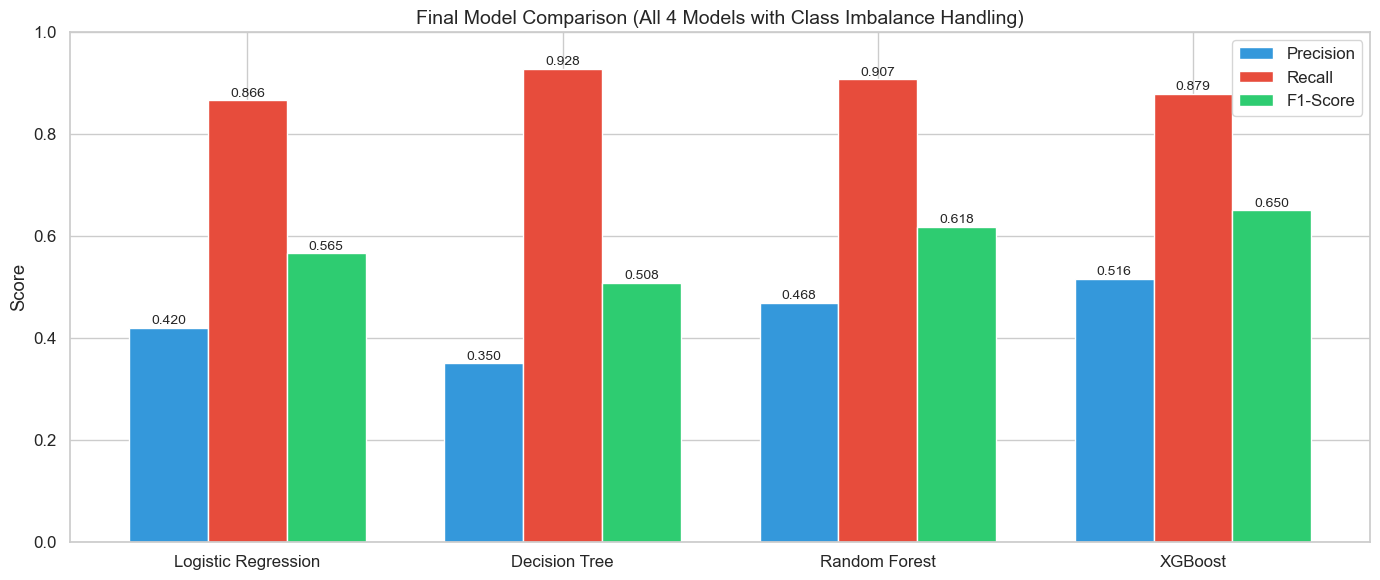

In [46]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
precision_scores = [
    precision_score(y_test, y_pred_weighted),
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xgb)
]
recall_scores = [
    recall_score(y_test, y_pred_weighted),
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]
f1_scores = [
    f1_score(y_test, y_pred_weighted),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recall_scores, width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Final Model Comparison (All 4 Models with Class Imbalance Handling)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('final_4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

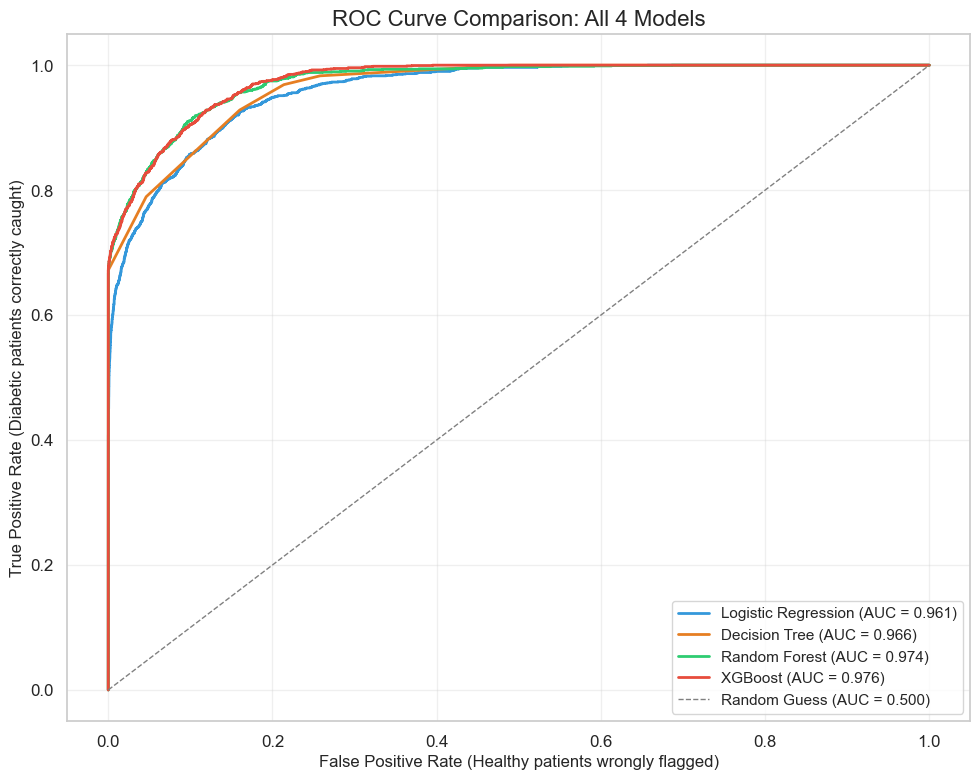

In [49]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for each model (not predictions, probabilities)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='#e67e22', linewidth=2, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.3f})')

# Random guess baseline
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Guess (AUC = 0.500)')

plt.title('ROC Curve Comparison: All 4 Models', fontsize=16)
plt.xlabel('False Positive Rate (Healthy patients wrongly flagged)', fontsize=12)
plt.ylabel('True Positive Rate (Diabetic patients correctly caught)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

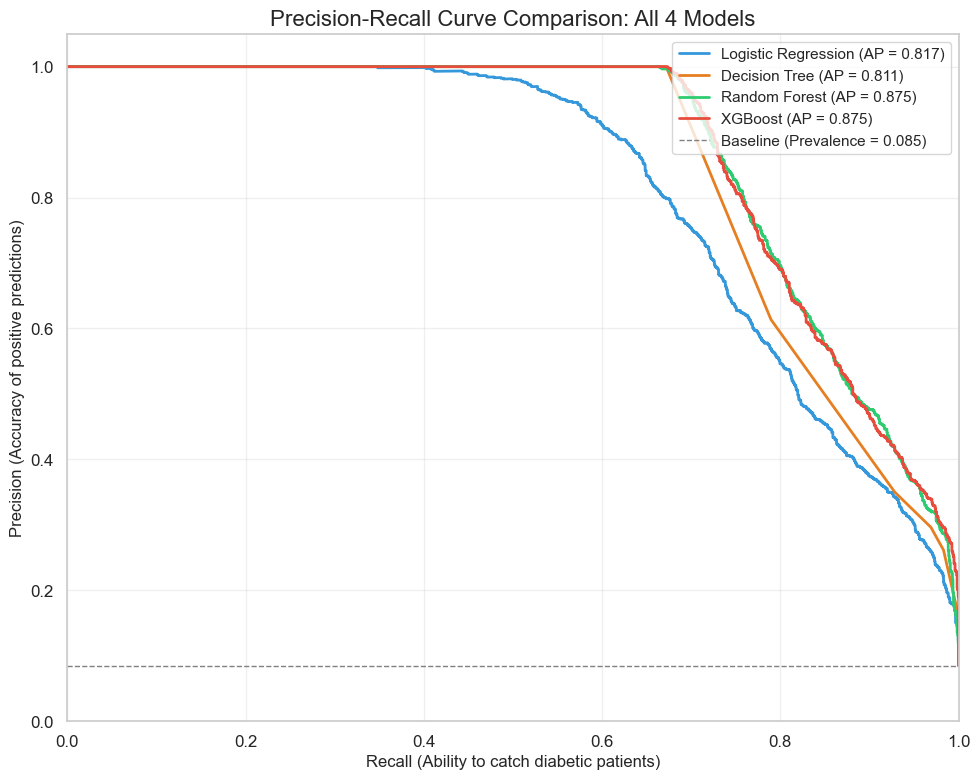

In [ ]:
0

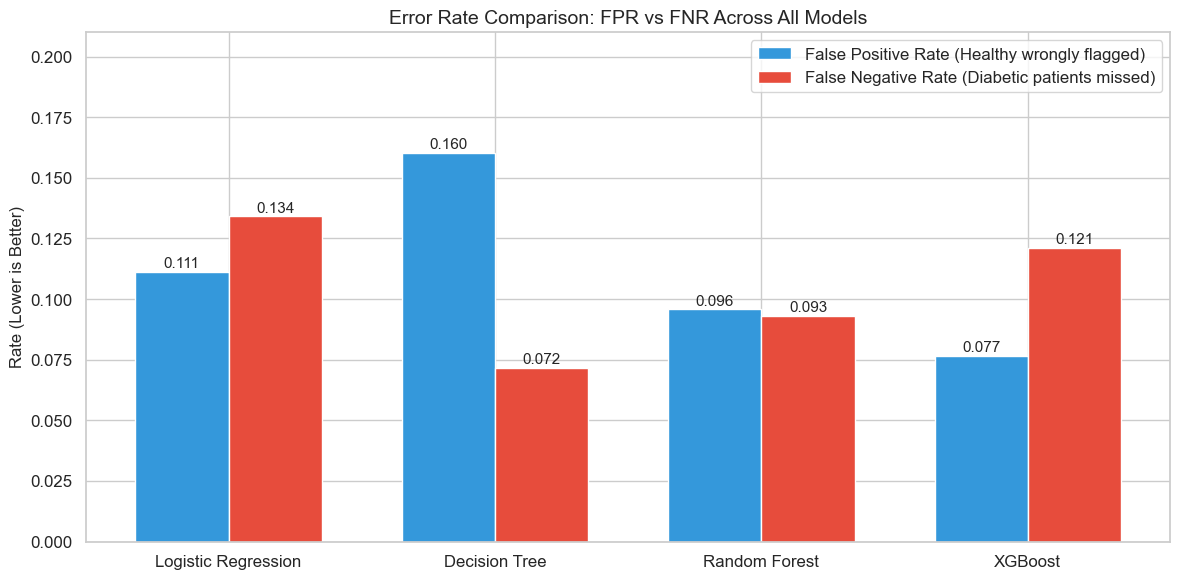

=== FPR and FNR Summary ===
              Model FPR (Healthy wrongly flagged) FNR (Diabetic missed)
Logistic Regression                         0.111                 0.134
      Decision Tree                         0.160                 0.072
      Random Forest                         0.096                 0.093
            XGBoost                         0.077                 0.121


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Calculate FPR and FNR for each model
def get_fpr_fnr(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)
    return FPR, FNR

fpr_lr, fnr_lr = get_fpr_fnr(y_test, y_pred_weighted)
fpr_dt, fnr_dt = get_fpr_fnr(y_test, y_pred_dt)
fpr_rf, fnr_rf = get_fpr_fnr(y_test, y_pred_rf)
fpr_xgb, fnr_xgb = get_fpr_fnr(y_test, y_pred_xgb)

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
fpr_scores = [fpr_lr, fpr_dt, fpr_rf, fpr_xgb]
fnr_scores = [fnr_lr, fnr_dt, fnr_rf, fnr_xgb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, fpr_scores, width, label='False Positive Rate (Healthy wrongly flagged)', color='#3498db')
bars2 = ax.bar(x + width/2, fnr_scores, width, label='False Negative Rate (Diabetic patients missed)', color='#e74c3c')

ax.set_ylabel('Rate (Lower is Better)', fontsize=12)
ax.set_title('Error Rate Comparison: FPR vs FNR Across All Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(max(fpr_scores), max(fnr_scores)) + 0.05)
ax.legend(loc='upper right')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('fpr_fnr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("=== FPR and FNR Summary ===")
summary = pd.DataFrame({
    'Model': models,
    'FPR (Healthy wrongly flagged)': [f'{x:.3f}' for x in fpr_scores],
    'FNR (Diabetic missed)': [f'{x:.3f}' for x in fnr_scores]
})
print(summary.to_string(index=False))

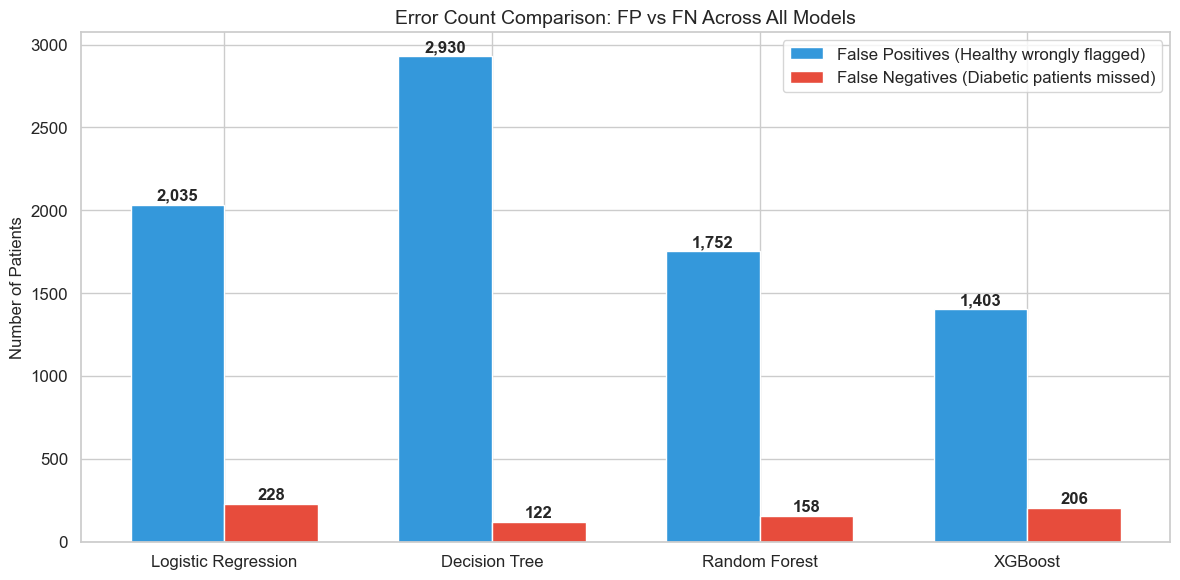

=== Error Count Summary (Out of 19,997 Test Patients) ===
Model                     FP (Wrongly Flagged) FN (Missed Diabetic)
-----------------------------------------------------------------
Logistic Regression                      2,035                  228
Decision Tree                            2,930                  122
Random Forest                            1,752                  158
XGBoost                                  1,403                  206

Note: Test set contains 18,297 healthy and 1,700 diabetic patients


In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Extract FP and FN counts for each model
def get_error_counts(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    return FP, FN

fp_lr, fn_lr = get_error_counts(y_test, y_pred_weighted)
fp_dt, fn_dt = get_error_counts(y_test, y_pred_dt)
fp_rf, fn_rf = get_error_counts(y_test, y_pred_rf)
fp_xgb, fn_xgb = get_error_counts(y_test, y_pred_xgb)

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
fp_counts = [fp_lr, fp_dt, fp_rf, fp_xgb]
fn_counts = [fn_lr, fn_dt, fn_rf, fn_xgb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, fp_counts, width, label='False Positives (Healthy wrongly flagged)', color='#3498db')
bars2 = ax.bar(x + width/2, fn_counts, width, label='False Negatives (Diabetic patients missed)', color='#e74c3c')

ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Error Count Comparison: FP vs FN Across All Models', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper right')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height):,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fp_fn_counts_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("=== Error Count Summary (Out of 19,997 Test Patients) ===")
print(f"{'Model':<25} {'FP (Wrongly Flagged)':>20} {'FN (Missed Diabetic)':>20}")
print("-" * 65)
for i, model in enumerate(models):
    print(f"{model:<25} {fp_counts[i]:>20,} {fn_counts[i]:>20,}")

print(f"\nNote: Test set contains {(y_test == 0).sum():,} healthy and {(y_test == 1).sum():,} diabetic patients")

In [69]:
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

In [70]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, confusion_matrix

thresholds = np.arange(0.0, 1.01, 0.01)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    results.append({
        "threshold": t,
        "recall": recall,
        "precision": precision,
        "FPR": fpr,
        "FNR": fnr
    })

In [71]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.head()

,threshold,recall,precision,FPR,FNR
0,0.00,1.0,0.085013,1.000000,0.0
1,0.01,1.0,0.159355,0.490135,0.0
2,0.02,1.0,0.159355,0.490135,0.0
3,0.03,1.0,0.159355,0.490135,0.0
4,0.04,1.0,0.159355,0.490135,0.0


In [ ]:
candidate = results_df[results_df["recall"] >= 0.92]
best_threshold = candidate.sort_values("precision", ascending=False).iloc[0]

print(best_threshold)

threshold    0.470000
recall       0.921765
precision    0.434072
FPR          0.111658
FNR          0.078235
Name: 47, dtype: float64


In [68]:
candidate = results_df[results_df["recall"] >= 0.92]
best_threshold = candidate.sort_values("precision", ascending=False).iloc[0]

print(best_threshold)

threshold    0.360000
recall       0.923529
precision    0.425590
FPR          0.115811
FNR          0.076471
Name: 36, dtype: float64


In [73]:
candidate = results_df[results_df["recall"] >= 0.93]
best_threshold = candidate.sort_values("precision", ascending=False).iloc[0]

print(best_threshold)

threshold    0.200000
recall       0.968824
precision    0.296223
FPR          0.213860
FNR          0.031176
Name: 20, dtype: float64


In [98]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def find_threshold_near_recall(y_true, y_prob, recall_target=0.92):

    thresholds = np.arange(0.01, 0.99, 0.01)
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        fpr = fp/(fp+tn)
        fnr = fn/(fn+tp)

        rows.append([t, precision, recall, fpr, fnr])

    df = pd.DataFrame(rows, columns=["threshold","precision","recall","FPR","FNR"])

    # distance from target recall
    df["recall_gap"] = abs(df["recall"] - recall_target)

    # first minimize recall gap, then maximize precision
    best = df.sort_values(["recall_gap","precision"], ascending=[True, False]).iloc[0]

    return best["threshold"], df

In [99]:
prob_lr  = lr_model.predict_proba(X_test_scaled)[:,1]
prob_dt  = dt_model.predict_proba(X_test_scaled)[:,1]
prob_rf  = rf_model.predict_proba(X_test_scaled)[:,1]
prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

In [100]:
thr_lr, df_lr = find_threshold_near_recall(y_test, prob_lr, 0.92)
thr_dt, df_dt = find_threshold_near_recall(y_test, prob_dt, 0.92)
thr_rf, df_rf = find_threshold_near_recall(y_test, prob_rf, 0.92)
thr_xgb, df_xgb = find_threshold_near_recall(y_test, prob_xgb, 0.92)

print("Best thresholds:")
print("Logistic Regression:", thr_lr)
print("Decision Tree:", thr_dt)
print("Random Forest:", thr_rf)
print("XGBoost:", thr_xgb)

Best thresholds:
Logistic Regression: 0.38
Decision Tree: 0.41000000000000003
Random Forest: 0.47000000000000003
XGBoost: 0.37


In [103]:
# Example tuned thresholds
thr_lr = thr_lr
thr_dt = thr_dt
thr_rf = thr_rf
thr_xgb = thr_xgb

# predicted probabilities
prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]
prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]
prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]
prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# predictions after tuning
y_pred_lr_tuned = (prob_lr >= thr_lr).astype(int)
y_pred_dt_tuned = (prob_dt >= thr_dt).astype(int)
y_pred_rf_tuned = (prob_rf >= thr_rf).astype(int)
y_pred_xgb_tuned = (prob_xgb >= thr_xgb).astype(int)

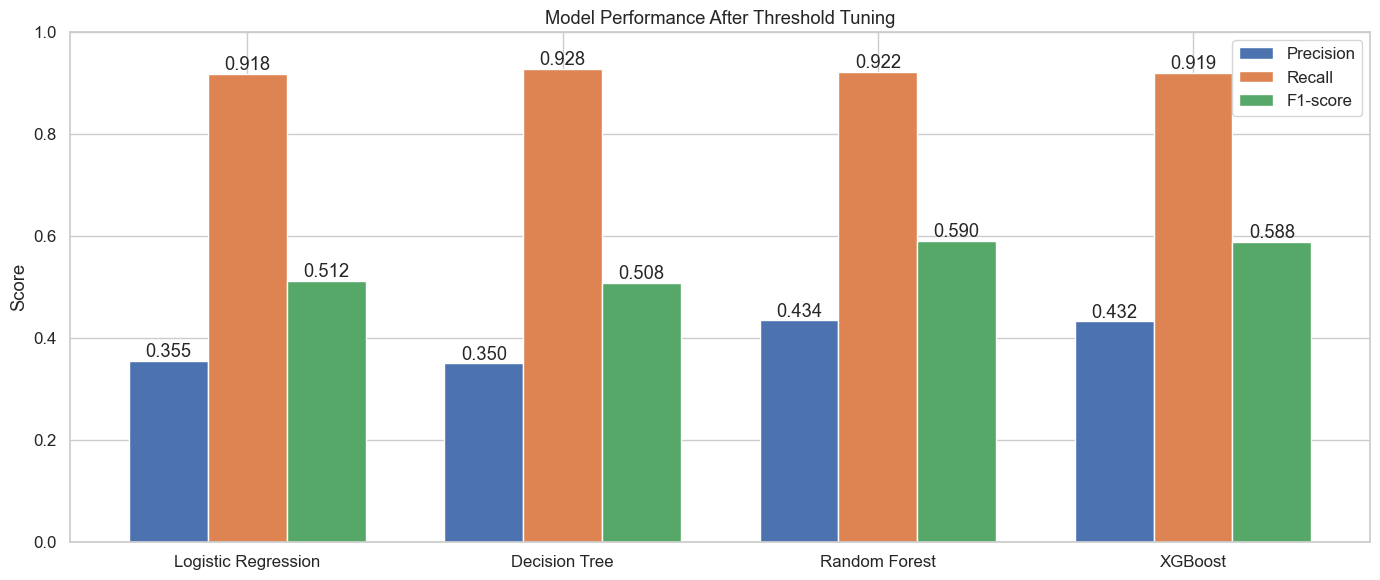

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

precision_scores = [
    precision_score(y_test, y_pred_lr_tuned),
    precision_score(y_test, y_pred_dt_tuned),
    precision_score(y_test, y_pred_rf_tuned),
    precision_score(y_test, y_pred_xgb_tuned)
]

recall_scores = [
    recall_score(y_test, y_pred_lr_tuned),
    recall_score(y_test, y_pred_dt_tuned),
    recall_score(y_test, y_pred_rf_tuned),
    recall_score(y_test, y_pred_xgb_tuned)
]

f1_scores = [
    f1_score(y_test, y_pred_lr_tuned),
    f1_score(y_test, y_pred_dt_tuned),
    f1_score(y_test, y_pred_rf_tuned),
    f1_score(y_test, y_pred_xgb_tuned)
]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14,6))

bars1 = ax.bar(x - width, precision_scores, width, label='Precision')
bars2 = ax.bar(x, recall_scores, width, label='Recall')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('Model Performance After Threshold Tuning')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0,1)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center')

plt.tight_layout()
plt.show()

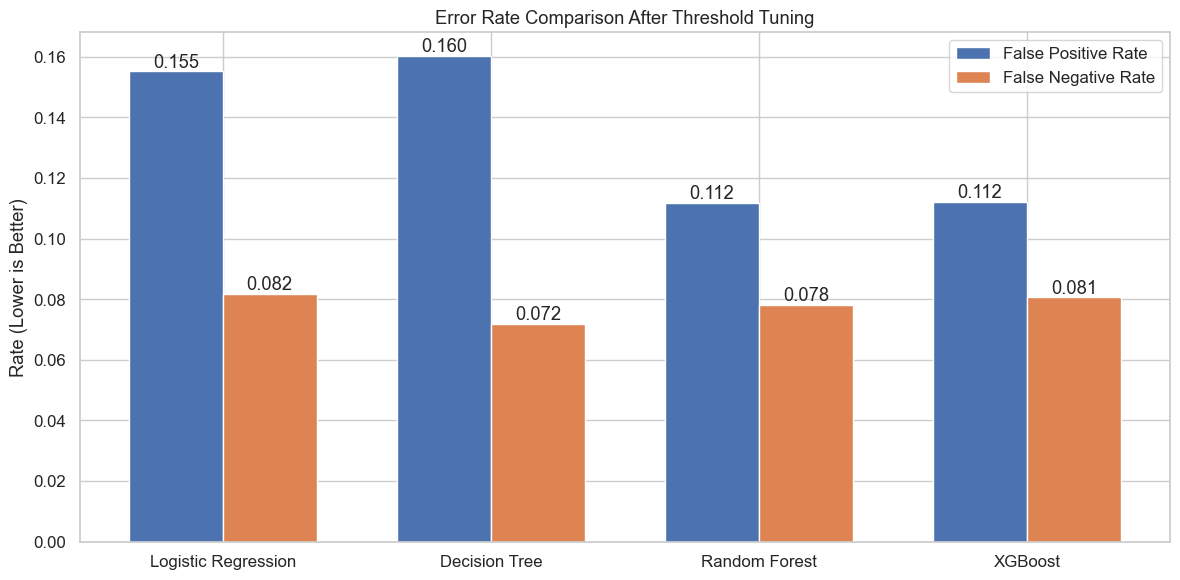

In [105]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def get_fpr_fnr(y_true, y_pred):
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)
    return FPR, FNR

fpr_lr, fnr_lr = get_fpr_fnr(y_test, y_pred_lr_tuned)
fpr_dt, fnr_dt = get_fpr_fnr(y_test, y_pred_dt_tuned)
fpr_rf, fnr_rf = get_fpr_fnr(y_test, y_pred_rf_tuned)
fpr_xgb, fnr_xgb = get_fpr_fnr(y_test, y_pred_xgb_tuned)

fpr_scores = [fpr_lr, fpr_dt, fpr_rf, fpr_xgb]
fnr_scores = [fnr_lr, fnr_dt, fnr_rf, fnr_xgb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

bars1 = ax.bar(x - width/2, fpr_scores, width,
               label='False Positive Rate')

bars2 = ax.bar(x + width/2, fnr_scores, width,
               label='False Negative Rate')

ax.set_ylabel('Rate (Lower is Better)')
ax.set_title('Error Rate Comparison After Threshold Tuning')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center')

plt.tight_layout()
plt.savefig('tuned_error_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [129]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Create explainer and calculate SHAP values
explainer = shap.TreeExplainer(rf_model)
X_sample = X_test_scaled.sample(n=2000, random_state=42)
shap_values = explainer(X_sample)
age_bin_cols = ['age_0-18', 'age_19-35', 'age_36-50', 'age_51-65', 'age_66-80']
keep_idx = [i for i, col in enumerate(X.columns.tolist()) if col not in age_bin_cols]

# 7. Filter SHAP values and underlying data to exclude age bins
# This helps focus the plot on continuous predictors
shap_values = shap_values[:, keep_idx]
# 2. Handle binary classification (Select Diabetes class)
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

# 3. Identify the Top 5 features based on mean absolute SHAP value
# We calculate the average "push" each feature has across all 2000 samples
global_importance = np.abs(shap_values.values).mean(0)
top_5_indices = np.argsort(global_importance) 

# 4. Filter the SHAP Explanation object to include only these 5 features
shap_values_top5 = shap_values[:, top_5_indices]


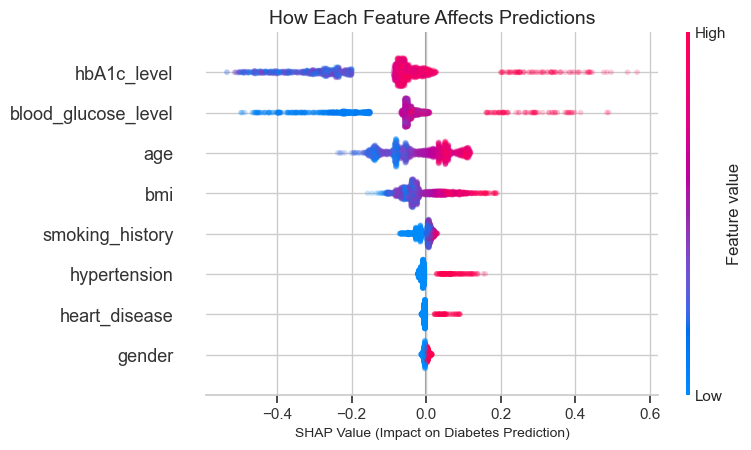

In [131]:

# 5. Plot the Beeswarm (Dot Plot)
# A height of 10 for only 5 features will ensure they are very spread out
plt.figure(figsize=(15, 10))

shap.plots.beeswarm(
    shap_values_top5, 
    show=False,
    color_bar=True,
    alpha=0.2
)

plt.title('How Each Feature Affects Predictions', fontsize=14)
plt.xlabel('SHAP Value (Impact on Diabetes Prediction)', fontsize=10)
plt.tight_layout()
plt.show()

In [132]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

train_pred = rf_model.predict(X_train_scaled)
test_pred = rf_model.predict(X_test_scaled)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

print("Train recall:", recall_score(y_train, train_pred))
print("Test recall:", recall_score(y_test, test_pred))

Train accuracy: 0.905219728699131
Test accuracy: 0.9044856728509276
Train recall: 0.9214705882352942
Test recall: 0.9070588235294118


In [140]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

# 1. Calculate metrics from your predictions
tr_acc = accuracy_score(y_train, train_pred)
te_acc = accuracy_score(y_test, test_pred)
tr_rec = recall_score(y_train, train_pred)
te_rec = recall_score(y_test, test_pred)

# 2. Create the flipped structure (Metrics as Rows, Splits as Columns)
data = {
    'Train': [tr_acc, tr_rec],
    'Test': [te_acc, te_rec],
    'Diff': [tr_acc - te_acc, tr_rec - te_rec]
}

df = pd.DataFrame(data, index=['Accuracy', 'Recall']).round(3)

# 3. Apply Option 1 styling: Frames, minimal padding, and narrow width
styled_df = df.style.set_table_styles([
    # Add borders to all cells and headers
    {'selector': 'th', 'props': [('border', '1px solid black'), ('padding', '4px 8px'), ('background-color', '#f2f2f2')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '4px 8px')]},
    # Force minimal width by removing extra spacing
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('margin', '0'), ('width', 'auto')]}
]).set_properties(**{'text-align': 'center', 'font-size': '12pt'})

# Display the styled table
styled_df

,Train,Test,Diff
Accuracy,0.905000,0.904000,0.001000
Recall,0.921000,0.907000,0.014000


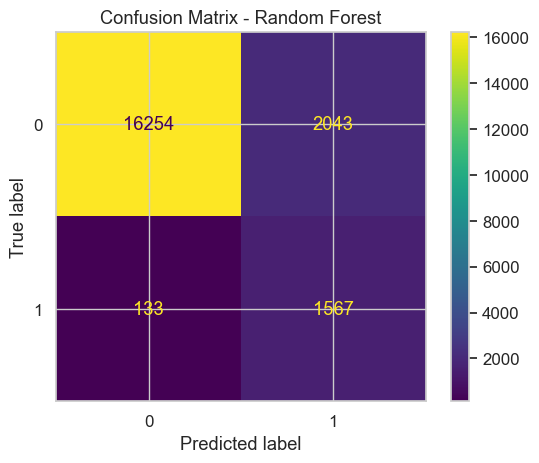

In [133]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_tuned)

plt.title("Confusion Matrix - Random Forest")
plt.show()

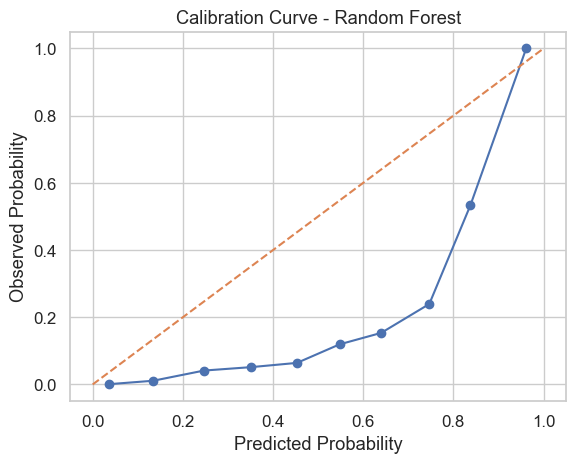

In [136]:
from sklearn.calibration import calibration_curve

prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

prob_true, prob_pred = calibration_curve(y_test, prob_rf, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve - Random Forest")
plt.show()